<a href="https://colab.research.google.com/github/MRaynardAlif/LinearRegressionTutorial/blob/main/Assignment_03_LINEAR_REGRESSION_20523167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1:
1.   Import Libraries that we need.
2.   Load the Dataset

In this case, we use the Air Conditioner (AC) Activity Dataset. Here is the example:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

data = pd.read_csv('/content/drive/MyDrive/Hvac_Dataset/AC3_Conditions.csv')

print(data.head())

print("\n===== DATA COUNT =====")
print(data.value_counts())

print("\n===== SUMMARY STATISTICS =====")
print(data.describe())

                  Time  Current (A)  Voltage (V)  Wattage (W)  \
0  2025-06-04 15:35:12         1.46       233.79       336.87   
1  2025-06-04 15:36:12         1.46       233.23       336.17   
2  2025-06-04 15:37:13         1.45       233.51       333.88   
3  2025-06-04 15:38:14         1.45       233.51       334.68   
4  2025-06-04 15:39:14         1.46       233.51       336.91   

   Temperature Indoor (°C)  Temperature Outdoor (°C) Condition  
0                     23.2                      27.8    Normal  
1                     23.1                      27.8    Normal  
2                     23.1                      27.8    Normal  
3                     23.1                      27.8    Normal  
4                     23.0                      27.8    Normal  

===== DATA COUNT =====
Time                 Current (A)  Voltage (V)  Wattage (W)  Temperature Indoor (°C)  Temperature Outdoor (°C)  Condition
2025-06-13 12:57:49  1.51         224.93       336.70       25.3          

#### Part 1.1: Feature Correlation Heatmap

To understand the relationships between different variables in the dataset, we can visualize their correlations using a heatmap. This helps in identifying highly correlated features, which can be useful for feature selection or understanding potential multicollinearity.

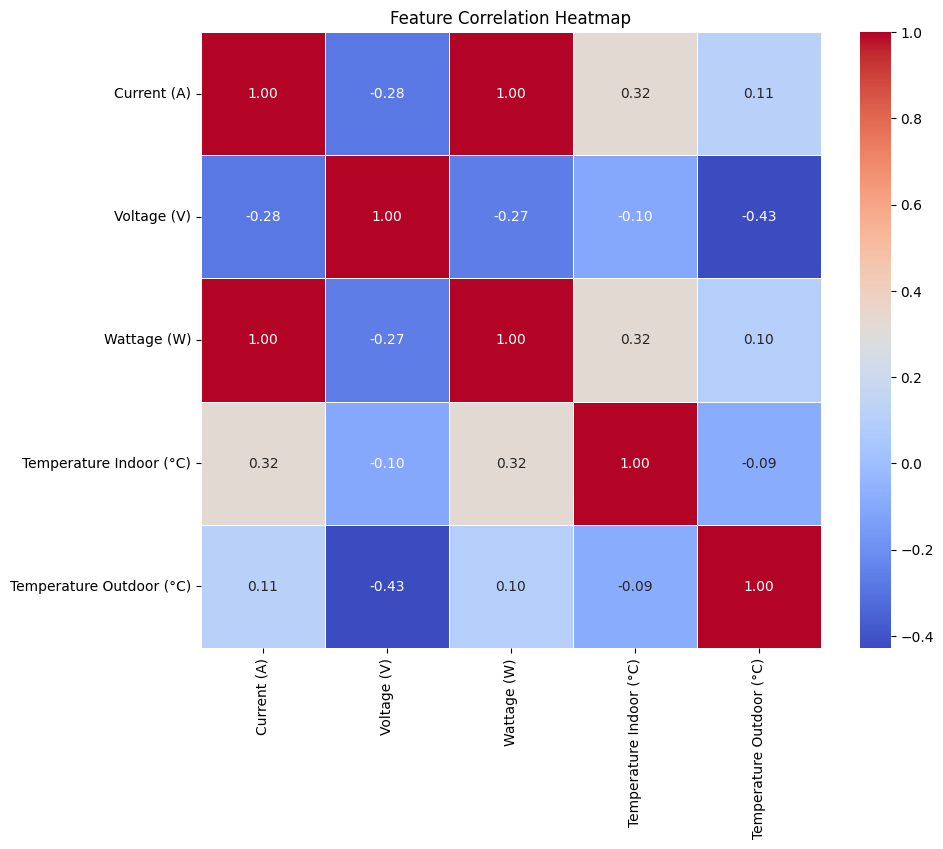

In [5]:
plt.figure(figsize=(10, 8))
correlation_matrix = data.select_dtypes(include=np.number).corr() # Calculate correlation matrix for numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.show()

 The colors in the heatmap indicate the strength and direction of the correlation. The numbers displayed within each cell of the heatmap are the correlation coefficients, which range from -1 to +1.


*   +1: A perfect positive linear relationship
*   -1: A perfect negative linear relationship
*    0: No linear relationship



From here, we can learn the correlation between features in the dataset. For example:
1. Current (A) and Wattage (W) have a correlation of 1.00. This confirms the very strong positive linear relationship between Current and Wattage.
2. Current (A) and Voltage (V) have a negative correlation of -0.28, indicating a weak inverse relationship.



### Part 2:
1. Simple Preprocessing (Feature Selection and Train-Test Split)
2. Model Training
3. Model Evaluation (with MSE)

Since the Dataset containing AC activity data, including the electrical data. We can use the AC Current (A) as X, and AC Wattage (W) as Y.

Next, split the data and fit the training data into the model. The test data will be used by the model to make prediction.

Finally, evaluate the model using Mean Squared Error and R^2 Score.


Here is the example:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Prepare features (X) and target (y)
# Setting X to only 'Temperature Indoor (°C)'
X = data[['Current (A)']]
y = data['Wattage (W)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')

# Display Coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients)

Mean Squared Error: 7.3589
R^2 Score: 0.9995


,Feature,Coefficient
0,Current (A),237.292386


From here, we can see that:


1.   Mean Squared Error (7.3589): This represents the average squared difference between actual and predicted wattage. Given the scale of wattage (often hundreds of watts), an error of ~2.7W (square root of MSE) is quite low.


2.   R² Score (0.9995): This is a near-perfect score,   indicating that 99.95% of the variance in Wattage is explained by the Current.

3.   Coefficient (237.292386): This simply means that for every one-unit increase in 'Current (A)', the predicted 'Wattage (W)' increases by approximately 237.29 Watts. It quantifies the strength and direction of the linear relationship between current and wattage, as learned by the model.



### Part 3:

Visualize the linear regression line (in red) against the actual data points (in blue).

Since Current and Wattage are linearly related (P ≈ V × I), the model fits the data extremely well, with the red line passing right through the center of the observations.

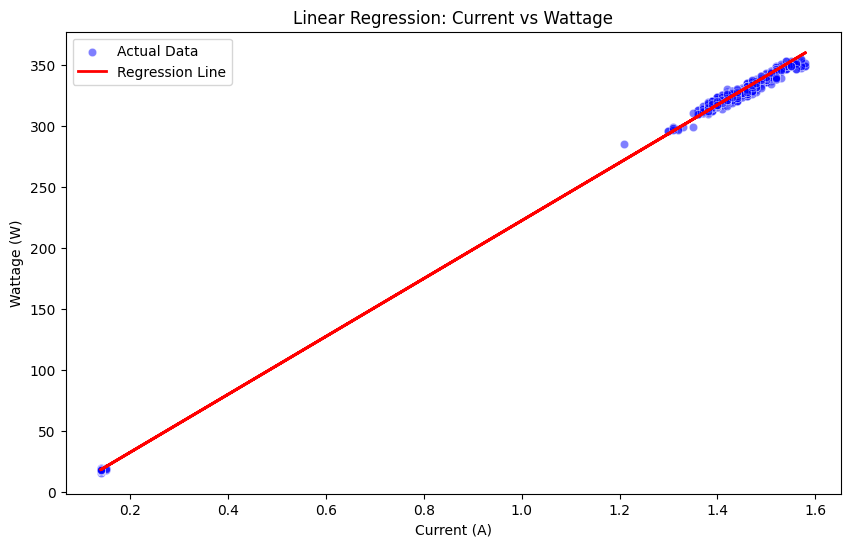

In [ ]:
plt.figure(figsize=(10, 6))
# Plot the actual testing data
sns.scatterplot(x=X_test['Current (A)'], y=y_test, color='blue', label='Actual Data', alpha=0.5)
# Plot the regression line
plt.plot(X_test['Current (A)'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Current (A)')
plt.ylabel('Wattage (W)')
plt.title('Linear Regression: Current vs Wattage')
plt.legend()
plt.show()

### Part 4:

This is the visualization to show how well the model's predictions align with the actual values:


1. Actual vs. Predicted Wattage (Left): The points form a very tight line along the red dashed diagonal. This indicates that the model's predictions are nearly identical to the actual values across the entire range of data.

2. Distribution of Residuals (Right): The error distribution is centered around zero and is very narrow. Most errors are within ±5 Watts, which is excellent given that the total wattage goes up to 340W.

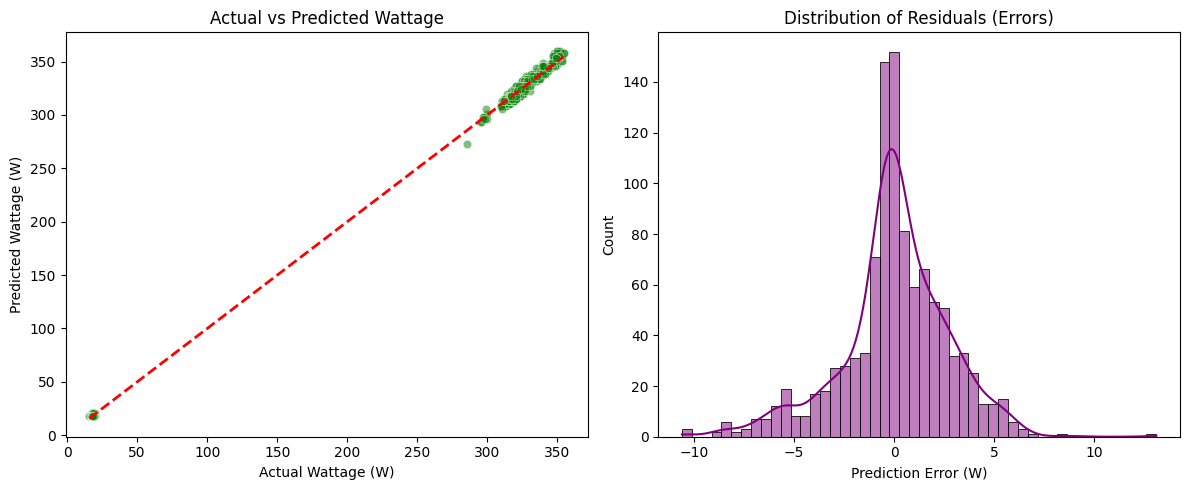

In [ ]:
plt.figure(figsize=(12, 5))

# Subplot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Wattage (W)')
plt.ylabel('Predicted Wattage (W)')
plt.title('Actual vs Predicted Wattage')

# Subplot 2: Residuals Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error (W)')

plt.tight_layout()
plt.show()

Overall, these plots confirm that the Linear Regression model using Current (A) is highly reliable for predicting Wattage (W).

Now, is this training result indicate overfitting? Since we can see such a high R-squared score. Generally, an R-squared of 0.9995 can indeed be a red flag for overfitting, especially in complex predictive models.

However, in this specific case (predicting Wattage from Current), the very high R-squared is expected and does not necessarily indicate overfitting. So, while it's good practice to be suspicious of nearly perfect scores, in this particular scenario, the results are consistent with the physical laws governing electricity and the nature of the data. The model is likely accurately capturing a very strong, nearly deterministic relationship.